# 1. Breast segmentation with R2AttU-Net

The first stage isolates the breasts so that downstream models only see breast tissue. The architecture is a recurrent residual U-Net with attention gates (R2AttU-Net) with configurable depth and width, trained on annotated clinical FLIR thermograms (one image per patient).

Three evaluations:

1. **Held-out split** of the clinical data: a binary breast/background variant (depth 7, 16 base filters, 39.5M parameters), 5 independent training runs.
2. **External clinical test set**: the released 3-class model (background / left / right breast; depth 6, 8 base filters, 2.5M parameters) on 21 images acquired separately from the training data.
3. **DMR-IR** (public, never used for training): the released model on all 1,000 images, compared with the dataset's own breast annotations.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS = Path("../results")
FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#8a8a85",
        "axes.labelcolor": "#2b2b29",
        "axes.titleweight": "bold",
        "xtick.color": "#5c5c58",
        "ytick.color": "#5c5c58",
        "axes.grid": True,
        "axes.grid.axis": "y",
        "axes.axisbelow": True,
        "grid.color": "#e4e4e0",
        "grid.linewidth": 0.8,
        "legend.frameon": False,
    }
)
# Categorical palette in fixed order (validated for colour-vision deficiencies).
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]

## 1.1 Held-out split (binary variant, 5 training runs)

In [2]:
runs = pd.read_csv(RESULTS / "segmentation_repeated_runs.csv")
metrics = ["dice", "iou", "precision", "recall (sensitivity)", "specificity", "auc"]
runs[metrics].agg(["mean", "std"]).T.round(3)

,mean,std
dice,0.783,0.060
iou,0.673,0.092
precision,0.874,0.144
recall (sensitivity),0.772,0.138
specificity,0.971,0.044
auc,0.934,0.046


## 1.2 External clinical test set

Released model (`configs/segmentation_best.json`) evaluated pixel-wise on the 21 external images. These images are private, so the evaluation cannot be re-run from this repository; the values below are the recorded results.

| Dice | IoU | Precision | Recall | Specificity |
|---:|---:|---:|---:|---:|
| 0.838 | 0.721 | 0.820 | 0.857 | 0.973 |

## 1.3 DMR-IR: zero-shot on a public dataset

Produced by `scripts/segmentation/evaluate_dmrir.py`. DMR-IR annotations mark both breasts and the region between them as a single area, while the model segments each breast separately, so recall is structurally capped; precision measures how much of the predicted area lies inside the annotated breast region.

In [3]:
dmrir = pd.read_csv(RESULTS / "segmentation_dmrir.csv")
cols = ["dice", "iou", "precision", "recall"]
summary = pd.DataFrame(
    {
        "per image (mean)": dmrir[cols].mean(),
        "per image (median)": dmrir[cols].median(),
        "per patient (mean)": dmrir.groupby("patient")[cols].mean().mean(),
    }
).round(3)
print(f"{len(dmrir)} images from {dmrir.patient.nunique()} patients")
summary

1000 images from 44 patients


,per image (mean),per image (median),per patient (mean)
dice,0.738,0.748,0.737
iou,0.589,0.598,0.589
precision,0.870,0.882,0.871
recall,0.646,0.654,0.644


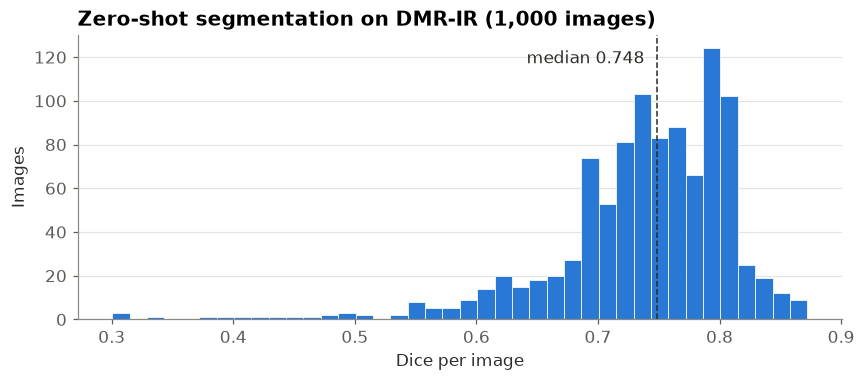

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(dmrir["dice"], bins=40, color=COLORS[0], edgecolor="white", linewidth=0.5)
ax.axvline(dmrir["dice"].median(), color="#2b2b29", linestyle="--", linewidth=1)
ax.annotate(
    f"median {dmrir['dice'].median():.3f}",
    (dmrir["dice"].median(), ax.get_ylim()[1] * 0.9),
    xytext=(-8, 0),
    textcoords="offset points",
    ha="right",
    color="#2b2b29",
)
ax.set_xlabel("Dice per image")
ax.set_ylabel("Images")
ax.set_title("Zero-shot segmentation on DMR-IR (1,000 images)", loc="left")
fig.tight_layout()